# **Dans quelle mesure la performance boursière de Nvidia reflète-t-elle une réelle création de valeur économique, et dans quelle mesure s’explique-t-elle par une hausse de sa valorisation sur les marchés ?**

# Combinaison finance d’entreprise (création de valeur) avec une question de finance de marché (valorisation).

In [2]:
# 1. Bibliothèques de base
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime
import statsmodels.api as sm

In [3]:
TICKERS = ["NVDA", "^IXIC", "^GSPC"]  # NVDA, Nasdaq Composite, S&P 500
START = "2016-01-01"
END = datetime.today().strftime("%Y-%m-%d")
prices = yf.download(TICKERS, start=START, end=END, auto_adjust=True)["Close"]
prices = prices.dropna()
prices.columns = ["NVDA", "NASDAQ", "S&P500"]
prices.head()

[*********************100%***********************]  3 of 3 completed


,NVDA,NASDAQ,S&P500
Date,,,
2016-01-04,0.789588,2012.660034,4903.089844
2016-01-05,0.802272,2016.709961,4891.430176
2016-01-06,0.769098,1990.260010,4835.759766
2016-01-07,0.738607,1943.089966,4689.430176
2016-01-08,0.722752,1922.030029,4643.629883


In [ ]:
# Rendements journaliers
daily_returns = prices.pct_change().dropna()
print("Rendements journaliers:")
print(daily_returns.head())


Rendements journaliers:
                NVDA    NASDAQ    S&P500
Date                                    
2016-01-05  0.016064  0.002012 -0.002378
2016-01-06 -0.041350 -0.013115 -0.011381
2016-01-07 -0.039644 -0.023700 -0.030260
2016-01-08 -0.021467 -0.010838 -0.009767
2016-01-11  0.001688  0.000853 -0.001214


In [ ]:
# Rendements mensuels
monthly_prices = prices.resample('ME').last()
monthly_returns = monthly_prices.pct_change().dropna()
print("\nRendements mensuels:")
print(monthly_returns.head())


Rendements mensuels:
                NVDA    NASDAQ    S&P500
Date                                    
2016-02-29  0.074573 -0.004128 -0.012137
2016-03-31  0.136161  0.065991  0.068430
2016-04-30 -0.002807  0.002699 -0.019403
2016-05-31  0.318360  0.015325  0.036163
2016-06-30  0.006207  0.000911 -0.021297


Cette partie sert à résumer la performance et le risque des actifs dans un tableau exploitable pour l’analyse financière.

In [ ]:
# Fonctions définies en premier
def annualized_vol(r, periods=12):
    return r.std() * np.sqrt(periods)

def max_drawdown(price_series):
    cum = (1 + price_series.pct_change().fillna(0)).cumprod()
    peak = cum.cummax()
    dd = cum / peak - 1
    return dd.min()

def get_drawdown_series(price_series):
    cum = (1 + price_series.pct_change().fillna(0)).cumprod()
    peak = cum.cummax()
    dd = cum / peak - 1
    return dd

# Volatilité annualisée
volatility = monthly_returns.std() * np.sqrt(12)


# Max Drawdown pour chaque ticker
print("\nMax Drawdown:")
for ticker in prices.columns:
    dd = max_drawdown(prices[ticker])

    # Summary table avec tous les métriques
summary = pd.DataFrame({
    "Rendement annuel moyen (%)": monthly_returns.mean() * 12 * 100,
    "Volatilité annualisée (%)": monthly_returns.std() * np.sqrt(12) * 100,
    "Max Drawdown (%)": [max_drawdown(prices[ticker]) * 100 for ticker in prices.columns]
}, index=prices.columns)

print("📊 RÉSUMÉ DES PERFORMANCES")
print("=" * 60)
print(summary.round(2))
print("=" * 60)


Max Drawdown:
📊 RÉSUMÉ DES PERFORMANCES
        Rendement annuel moyen (%)  Volatilité annualisée (%)  \
NVDA                         67.25                      47.05   
NASDAQ                       13.73                      14.92   
S&P500                       17.54                      17.99   

        Max Drawdown (%)  
NVDA              -66.34  
NASDAQ            -33.92  
S&P500            -36.40  


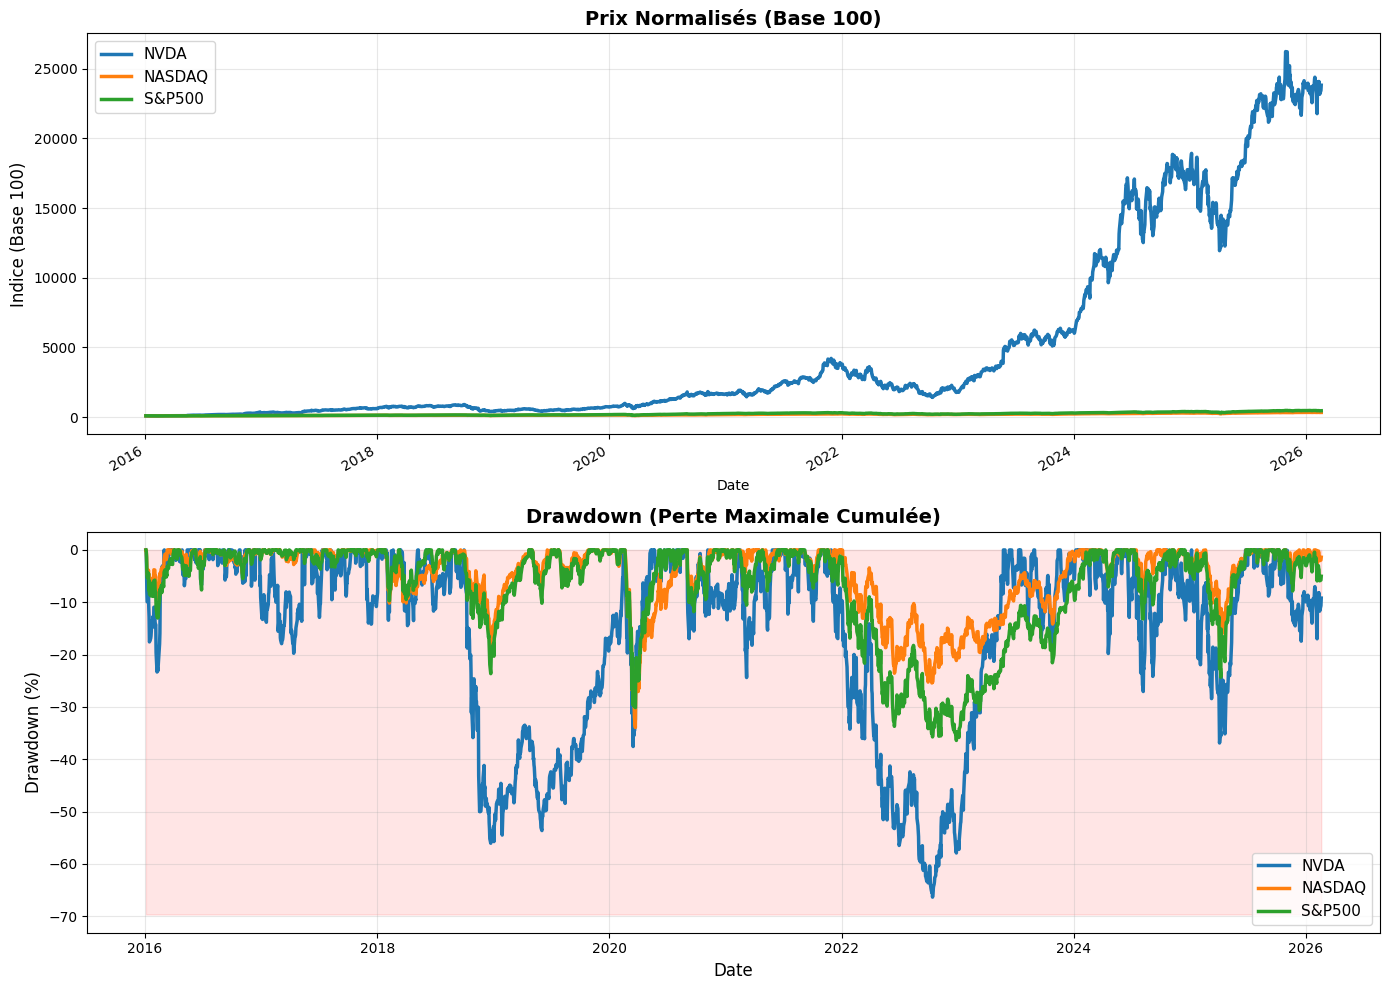

In [ ]:
# GRAPHIQUES
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 1. Prix normalisés (base 100)
normalized_prices = (prices / prices.iloc[0]) * 100
normalized_prices.plot(ax=axes[0], linewidth=2.5, grid=True)
axes[0].set_title("Prix Normalisés (Base 100)", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Indice (Base 100)", fontsize=12)
axes[0].legend(fontsize=11, loc='upper left')
axes[0].grid(True, alpha=0.3)

# 2. Drawdown pour chaque ticker
for ticker in prices.columns:
    dd_series = get_drawdown_series(prices[ticker])
    axes[1].plot(dd_series.index, dd_series * 100, label=ticker, linewidth=2.5)

axes[1].set_title("Drawdown (Perte Maximale Cumulée)", fontsize=14, fontweight='bold')
axes[1].set_ylabel("Drawdown (%)", fontsize=12)
axes[1].set_xlabel("Date", fontsize=12)
axes[1].legend(fontsize=11, loc='lower right')
axes[1].grid(True, alpha=0.3)
axes[1].fill_between(prices.index, 0, axes[1].get_ylim()[0], alpha=0.1, color='red')

plt.tight_layout()
plt.savefig('nvidia_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# ETATS FINANCIERS NVDA

import yfinance as yf
import pandas as pd
import numpy as np

# ---------- Réglages affichage ----------
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 1200)

# ---------- Fonction format milliards / millions ----------
def fmt_billions(x):
    if pd.isna(x):
        return np.nan
    if abs(x) >= 1e9:
        return f"{x/1e9:,.2f} B"
    if abs(x) >= 1e6:
        return f"{x/1e6:,.2f} M"
    return f"{x:,.0f}"

# ---------- Télécharger données ----------
nvda = yf.Ticker("NVDA")

income = nvda.financials.T  # compte de résultat (annuel)
balance = nvda.balance_sheet.T # bilan (annuel)
cash = nvda.cashflow.T # cash-flow (annuel)

# ---------- Convertir index en dates ----------
for df in [income, balance, cash]:
    df.index = pd.to_datetime(df.index)

# ---------- Sélection variables clés ----------
income_cols = [
    "Total Revenue",
    "Gross Profit",
    "EBITDA",
    "Operating Income",
    "Net Income",
    "Research And Development",
    "Selling General And Administration"
]

income_clean = income[income_cols].copy()

# ---------- Renommer  ----------
rename_map = {
    "Total Revenue": "Chiffre d'affaires",
    "Gross Profit": "Marge brute",
    "EBITDA": "EBITDA",
    "Operating Income": "EBIT (Operating Income)",
    "Net Income": "Résultat net",
    "Research And Development": "R&D",
    "Selling General And Administration": "SG&A"
}

income_clean = income_clean.rename(columns=rename_map)


income_clean = income_clean.sort_index()

income_display = income_clean.applymap(fmt_billions)


print("\n===== Etats fi NVDA  =====\n")
display(income_display)




===== Etats fi NVDA  =====



/tmp/ipython-input-4130843490.py:61: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  income_display = income_clean.applymap(fmt_billions)


,Chiffre d'affaires,Marge brute,EBITDA,EBIT (Operating Income),Résultat net,R&D,SG&A
2022-01-31,26.91 B,17.48 B,11.35 B,10.04 B,9.75 B,5.27 B,2.17 B
2023-01-31,26.97 B,15.36 B,5.99 B,5.58 B,4.37 B,7.34 B,2.44 B
2024-01-31,60.92 B,44.30 B,35.58 B,32.97 B,29.76 B,8.68 B,2.65 B
2025-01-31,130.50 B,97.86 B,86.14 B,81.45 B,72.88 B,12.91 B,3.49 B


In [ ]:
fund["OperatingMargin"] = fund["OperatingIncome"] / fund["Revenue"]
fund["NetMargin"] = fund["NetIncome"] / fund["Revenue"]
fund["FCF_Margin"] = fund["FCF"] / fund["Revenue"]
fund["ROE"] = fund["NetIncome"] / fund["TotalEquity"]
fund["ROA"] = fund["NetIncome"] / fund["TotalAssets"]


# ==============================
# VERSION AFFICHAGE LISIBLE FUND
# ==============================

import numpy as np

fund_display = fund.copy()

# ---- colonnes montants ----
amount_cols = [
    "Revenue","OperatingIncome","NetIncome","CFO","Capex","FCF",
    "TotalAssets","TotalEquity","TotalDebt"
]

# ---- colonnes ratios ----
ratio_cols = [
    "OperatingMargin","NetMargin","ROE","ROA","FCF_Margin","Leverage"
]

# ---- format montants B/M ----
def fmt_bm(x):
    if np.isnan(x):
        return ""
    if abs(x) >= 1e9:
        return f"{x/1e9:,.2f} B"
    if abs(x) >= 1e6:
        return f"{x/1e6:,.2f} M"
    return f"{x:,.0f}"

# ---- format % ----
def fmt_pct(x):
    if np.isnan(x):
        return ""
    return f"{x*100:.1f}%"

# appliquer format
for c in amount_cols:
    if c in fund_display.columns:
        fund_display[c] = fund_display[c].apply(fmt_bm)

for c in ratio_cols:
    if c in fund_display.columns:
        fund_display[c] = fund_display[c].apply(fmt_pct)

print("\n===== FUNDAMENTAUX NVDA — VERSION LISIBLE =====\n")
display(fund_display)




===== FUNDAMENTAUX NVDA — VERSION LISIBLE =====



,Revenue,OperatingIncome,NetIncome,CFO,Capex,FCF,TotalAssets,TotalEquity,TotalDebt,OpMargin,NetMargin,ROA,ROE,FCF_Margin,Leverage,OperatingMargin
2022-01-31,26.91 B,10.04 B,9.75 B,9.11 B,,,44.19 B,26.61 B,10.95 B,0.373077,36.2%,22.1%,36.6%,,41.1%,37.3%
2023-01-31,26.97 B,5.58 B,4.37 B,5.64 B,,,41.18 B,22.10 B,9.70 B,0.206755,16.2%,10.6%,19.8%,,43.9%,20.7%
2024-01-31,60.92 B,32.97 B,29.76 B,28.09 B,,,65.73 B,42.98 B,8.46 B,0.541217,48.8%,45.3%,69.2%,,19.7%,54.1%
2025-01-31,130.50 B,81.45 B,72.88 B,64.09 B,,,111.60 B,79.33 B,8.46 B,0.624175,55.8%,65.3%,91.9%,,10.7%,62.4%


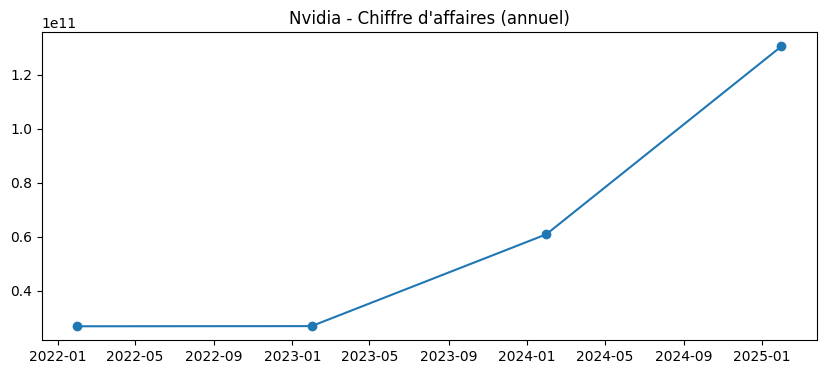

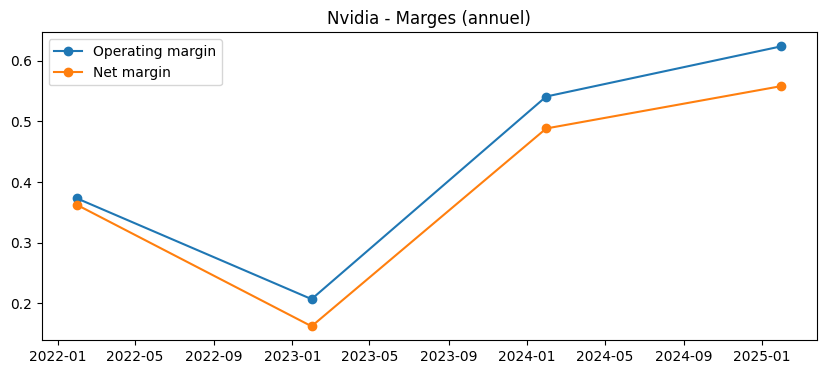

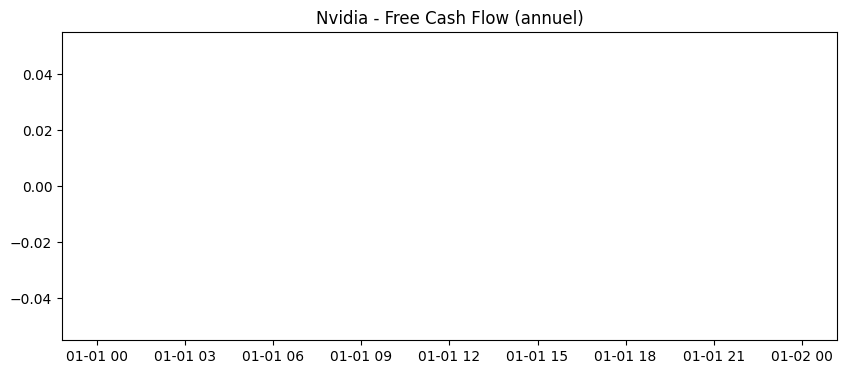

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(fund.index, fund["Revenue"], marker="o")
plt.title("Nvidia - Chiffre d'affaires (annuel)")
plt.show()

plt.figure(figsize=(10,4))
plt.plot(fund.index, fund["OperatingMargin"], marker="o", label="Operating margin")
plt.plot(fund.index, fund["NetMargin"], marker="o", label="Net margin")
plt.title("Nvidia - Marges (annuel)")
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(fund.index, fund["FCF"], marker="o")
plt.title("Nvidia - Free Cash Flow (annuel)")
plt.show()


                     CFO         Capex           FCF
2022-01-31  9.108000e+09 -9.760000e+08  8.132000e+09
2023-01-31  5.641000e+09 -1.833000e+09  3.808000e+09
2024-01-31  2.809000e+10 -1.069000e+09  2.702100e+10
2025-01-31  6.408900e+10 -3.236000e+09  6.085300e+10


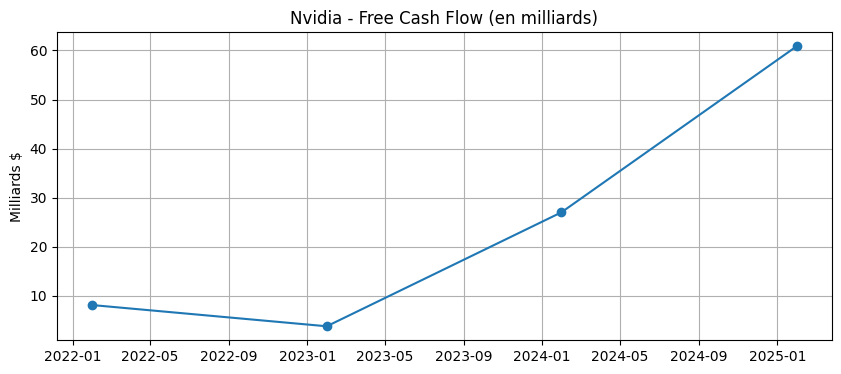

In [ ]:
fund["Capex"] = pick_col(
    cash,
    [
        "Capital Expenditures",
        "Capital Expenditure",
        "Purchase Of Property Plant Equipment",
        "Payments To Acquire Property Plant Equipment",
        "Investments In Property Plant Equipment"
    ]
)
fund["FCF"] = fund["CFO"] + fund["Capex"]
print(fund[["CFO","Capex","FCF"]])
plt.figure(figsize=(10,4))
plt.plot(fund.index, fund["FCF"]/1e9, marker="o")
plt.title("Nvidia - Free Cash Flow (en milliards)")
plt.ylabel("Milliards $")
plt.grid(True)
plt.show()



Valorisation : “le marché paie-t-il plus cher ?”

In [ ]:
info = nvda.info

multiples_now = {
    "marketCap": info.get("marketCap"),
    "trailingPE": info.get("trailingPE"),
    "forwardPE": info.get("forwardPE"),
    "priceToSalesTrailing12Months": info.get("priceToSalesTrailing12Months"),
    "enterpriseValue": info.get("enterpriseValue"),
    "enterpriseToRevenue": info.get("enterpriseToRevenue"),
    "enterpriseToEbitda": info.get("enterpriseToEbitda")
}

multiples_now


{'marketCap': 4547289284608,
 'trailingPE': 46.230198,
 'forwardPE': 24.071617,
 'priceToSalesTrailing12Months': 24.298605,
 'enterpriseValue': 4518127861760,
 'enterpriseToRevenue': 24.143,
 'enterpriseToEbitda': 40.091}

Valorisation “historique” simple : prix vs bénéfices (approx)

si cours monte beaucoup plus vite que Net Income, alors la valorisation joue un rôle majeur.


/tmp/ipython-input-3455020317.py:6: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  px_y = prices["NVDA"].resample("Y").last()


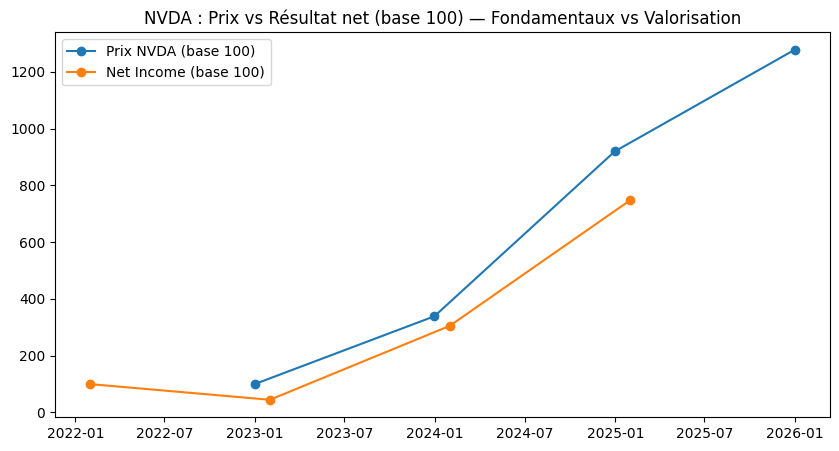

In [ ]:
# on met Net Income en base 100 (annuel)
ni = fund["NetIncome"].dropna()
ni_base = (ni / ni.iloc[0]) * 100

# prix annuel (fin d'année) en base 100
px_y = prices["NVDA"].resample("Y").last()
px_y = px_y[px_y.index.year.isin(ni.index.year)]
px_base = (px_y / px_y.iloc[0]) * 100

plt.figure(figsize=(10,5))
plt.plot(px_base.index, px_base.values, marker="o", label="Prix NVDA (base 100)")
plt.plot(ni_base.index, ni_base.values, marker="o", label="Net Income (base 100)")
plt.title("NVDA : Prix vs Résultat net (base 100) — Fondamentaux vs Valorisation")
plt.legend()
plt.show()


In [ ]:
def show_pct(x):
    return "NA" if pd.isna(x) else f"{x:.2%}"

last = fund.sort_index().iloc[-1]

print("---- Synthèse Nvidia ----")
print(f"Dernière année disponible : {fund.sort_index().index[-1].date()}")
print(f"Marge opérationnelle : {show_pct(last.get('OperatingMargin'))}")
print(f"Marge nette          : {show_pct(last.get('NetMargin'))}")
print(f"FCF margin           : {show_pct(last.get('FCF_Margin'))}")
print(f"ROE                  : {show_pct(last.get('ROE'))}")



---- Synthèse Nvidia ----
Dernière année disponible : 2025-01-31
Marge opérationnelle : 62.42%
Marge nette          : 55.85%
FCF margin           : NA
ROE                  : 91.87%


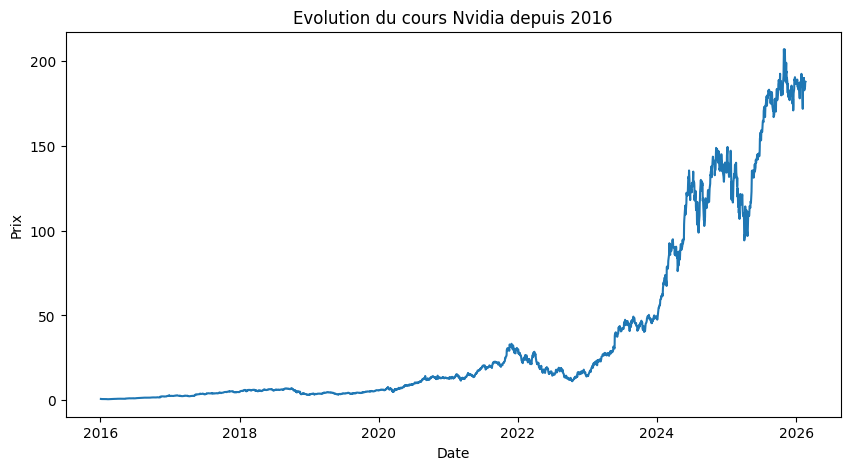

In [ ]:
nvda_price = data["NVDA"]

plt.figure(figsize=(10,5))
plt.plot(nvda_price.index, nvda_price)
plt.title("Evolution du cours Nvidia depuis 2016")
plt.xlabel("Date")
plt.ylabel("Prix")
plt.show()


In [ ]:
print("First 10 market caps:")
for i, (ticker, mc) in enumerate(market_caps.items()):
    if i >= 10:
        break
    print(f"{ticker}: {mc:,}")

First 10 market caps:
NVDA: 4,574,801,297,408
AAPL: 3,829,985,181,696
MSFT: 2,961,505,255,424
AMZN: 2,199,155,900,416
GOOGL: 3,663,576,694,784
GOOG: 3,672,165,318,656
META: 1,631,006,883,840
AVGO: 1,583,537,979,392
TSLA: 1,544,913,682,432
WMT: 995,569,958,912


In [ ]:
sp500_tickers = [c['Ticker'] for c in sp_constituents]

sp500_market_caps_dict = {ticker: market_caps[ticker] for ticker in sp500_tickers if ticker in market_caps}

sp500_market_caps_series = pd.Series(sp500_market_caps_dict)
total_sp500_market_cap = sp500_market_caps_series.sum()

nvda_market_cap_val = market_caps.get('NVDA', 0) # Get Nvidia's market cap, default to 0 if not found

nvda_weight_sp500 = nvda_market_cap_val / total_sp500_market_cap if total_sp500_market_cap > 0 else 0

rest_of_sp500_market_cap = total_sp500_market_cap - nvda_market_cap_val
rest_of_sp500_weight = rest_of_sp500_market_cap / total_sp500_market_cap if total_sp500_market_cap > 0 else 0

# Store weights for later use
sp500_weights = {
    'NVIDIA': nvda_weight_sp500,
    'Rest of S&P500': rest_of_sp500_weight
}

print(f"Nvidia's Market Cap in S&P500: {nvda_market_cap_val:,.2f}")
print(f"Total S&P500 Market Cap: {total_sp500_market_cap:,.2f}")
print(f"Nvidia's Weight in S&P500: {nvda_weight_sp500:.2%}")
print(f"Rest of S&P500 Weight: {rest_of_sp500_weight:.2%}")
print(sp500_weights)

Nvidia's Market Cap in S&P500: 4,574,801,297,408.00
Total S&P500 Market Cap: 65,223,810,291,712.00
Nvidia's Weight in S&P500: 7.01%
Rest of S&P500 Weight: 92.99%
{'NVIDIA': np.float64(0.07014004972949764), 'Rest of S&P500': np.float64(0.9298599502705024)}


In [ ]:
ndx_tickers = [c['Ticker'] for c in ndx_constituents]

ndx_market_caps_dict = {ticker: market_caps[ticker] for ticker in ndx_tickers if ticker in market_caps}

ndx_market_caps_series = pd.Series(ndx_market_caps_dict)
total_ndx_market_cap = ndx_market_caps_series.sum()

major_ndx_stocks = ['NVDA', 'AAPL', 'MSFT', 'AMZN', 'GOOGL', 'GOOG', 'META', 'AVGO', 'TSLA', 'COST'] # Adding a few other major large-cap stocks

ndx_weights = {}
sum_major_market_caps = 0

print(f"Total Nasdaq 100 Market Cap: {total_ndx_market_cap:,.2f}\n")

for ticker in major_ndx_stocks:
    if ticker in ndx_market_caps_dict:
        mc_val = ndx_market_caps_dict[ticker]
        weight = mc_val / total_ndx_market_cap if total_ndx_market_cap > 0 else 0
        ndx_weights[ticker] = weight
        sum_major_market_caps += mc_val
        print(f"{ticker}'s Market Cap: {mc_val:,.2f}, Weight in Nasdaq 100: {weight:.2%}")
    else:
        print(f"Market cap not found for {ticker} in Nasdaq 100 data.")

rest_of_ndx_market_cap = total_ndx_market_cap - sum_major_market_caps
rest_of_ndx_weight = rest_of_ndx_market_cap / total_ndx_market_cap if total_ndx_market_cap > 0 else 0
ndx_weights['Rest of Nasdaq 100'] = rest_of_ndx_weight

print(f"\nSum of Major Stocks Market Caps: {sum_major_market_caps:,.2f}")
print(f"Rest of Nasdaq 100 Market Cap: {rest_of_ndx_market_cap:,.2f}")
print(f"Rest of Nasdaq 100 Weight: {rest_of_ndx_weight:.2%}")

print("\n📊 Nasdaq 100 Allocation Summary")
print("=" * 60)
for ticker, weight in ndx_weights.items():
    print(f"{ticker:<20}: {weight:.2%}")
print("=" * 60)

Total Nasdaq 100 Market Cap: 37,088,190,883,840.00

NVDA's Market Cap: 4,574,801,297,408.00, Weight in Nasdaq 100: 12.33%
AAPL's Market Cap: 3,829,985,181,696.00, Weight in Nasdaq 100: 10.33%
MSFT's Market Cap: 2,961,505,255,424.00, Weight in Nasdaq 100: 7.99%
AMZN's Market Cap: 2,199,155,900,416.00, Weight in Nasdaq 100: 5.93%
GOOGL's Market Cap: 3,663,576,694,784.00, Weight in Nasdaq 100: 9.88%
GOOG's Market Cap: 3,672,165,318,656.00, Weight in Nasdaq 100: 9.90%
META's Market Cap: 1,631,006,883,840.00, Weight in Nasdaq 100: 4.40%
AVGO's Market Cap: 1,583,537,979,392.00, Weight in Nasdaq 100: 4.27%
TSLA's Market Cap: 1,544,913,682,432.00, Weight in Nasdaq 100: 4.17%
COST's Market Cap: 438,550,298,624.00, Weight in Nasdaq 100: 1.18%

Sum of Major Stocks Market Caps: 26,099,198,492,672.00
Rest of Nasdaq 100 Market Cap: 10,988,992,391,168.00
Rest of Nasdaq 100 Weight: 29.63%

📊 Nasdaq 100 Allocation Summary
NVDA                : 12.33%
AAPL                : 10.33%
MSFT                : 7

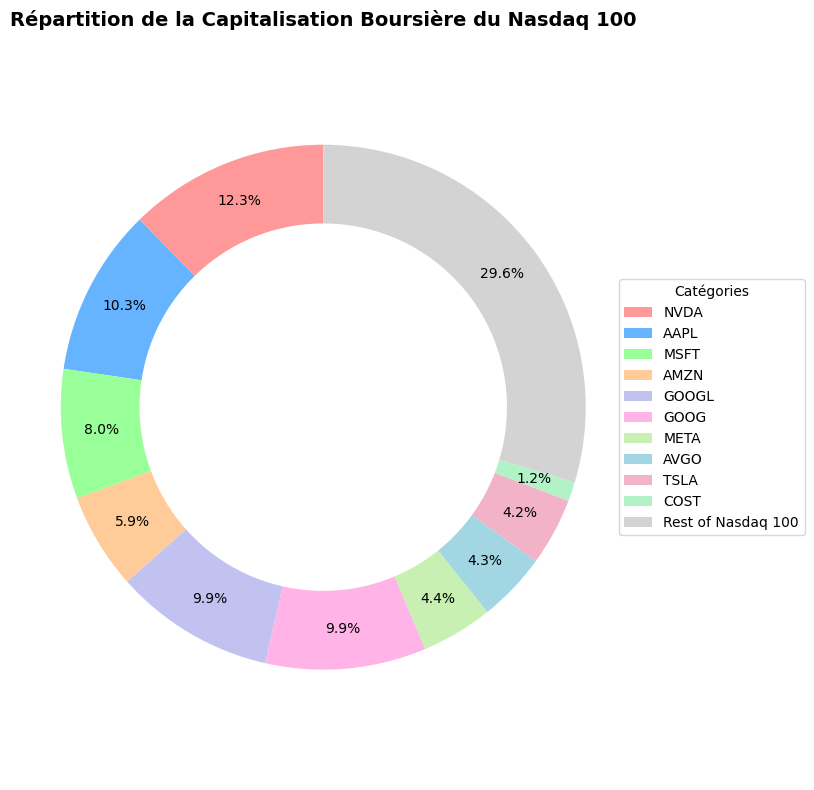

In [ ]:
# Nasdaq 100 Donut Chart
labels_ndx = list(ndx_weights.keys())
sizes_ndx = [ndx_weights[key] for key in labels_ndx]

# Define custom colors
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0','#ffb3e6','#c7f0b2','#a1d6e2','#f2b2c7','#b2f2c7', '#d3d3d3']

fig2, ax2 = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax2.pie(sizes_ndx,
                                   autopct='%1.1f%%',
                                   startangle=90,
                                   pctdistance=0.85,
                                   colors=colors)

# Draw circle
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig2.gca().add_artist(centre_circle)

ax2.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
ax2.set_title("Répartition de la Capitalisation Boursière du Nasdaq 100", fontsize=14, fontweight='bold')
ax2.legend(wedges, labels_ndx, title="Catégories", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.tight_layout()
plt.show()

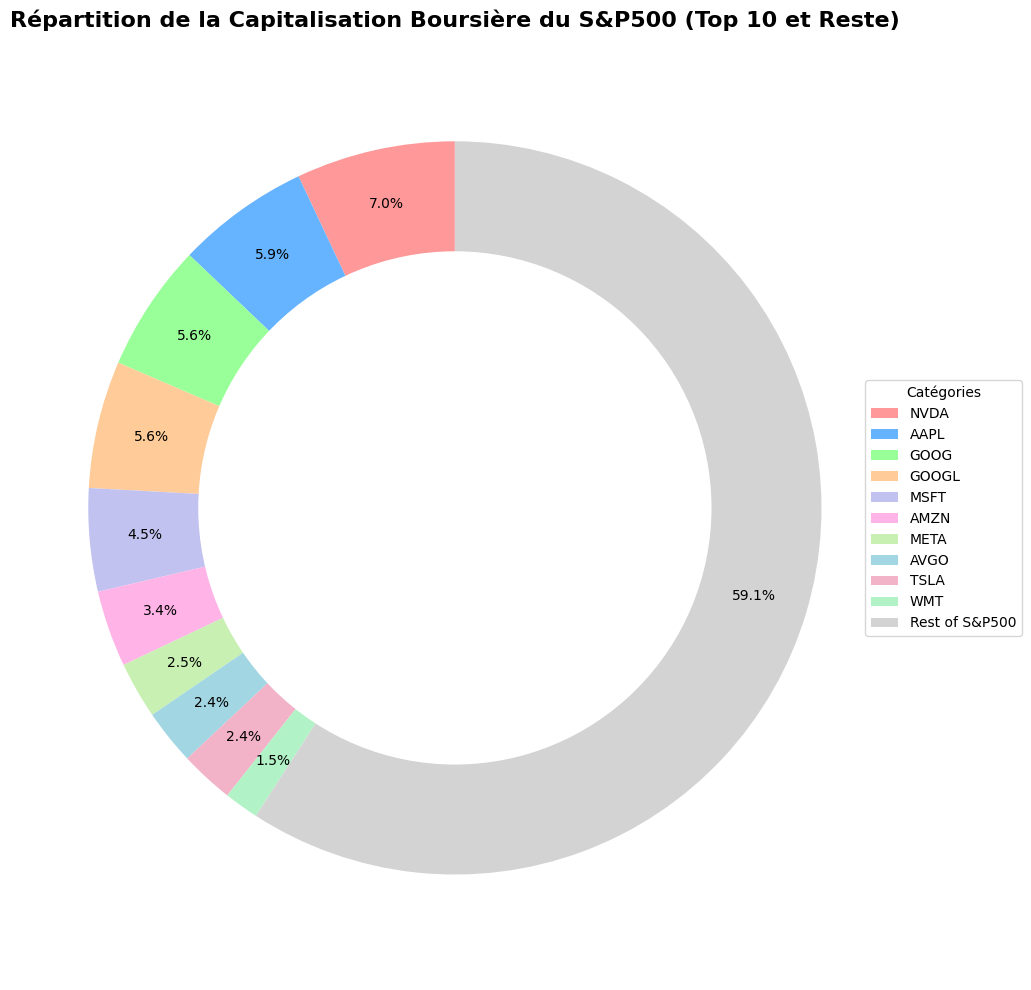

In [ ]:
import matplotlib.pyplot as plt

# Prepare data for the donut chart
labels_sp500_top10 = list(sp500_top10_weights.keys())
sizes_sp500_top10 = [sp500_top10_weights[key] for key in labels_sp500_top10]

# Define custom colors for better visualization
colors_sp500 = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0', '#ffb3e6', '#c7f0b2', '#a1d6e2', '#f2b2c7', '#b2f2c7', '#d3d3d3']

fig, ax = plt.subplots(figsize=(10, 10))
wedges, texts, autotexts = ax.pie(sizes_sp500_top10,
                                   autopct='%1.1f%%',
                                   startangle=90,
                                   pctdistance=0.85,
                                   colors=colors_sp500)

# Draw circle for the donut effect
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

ax.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
ax.set_title("Répartition de la Capitalisation Boursière du S&P500 (Top 10 et Reste)", fontsize=16, fontweight='bold')
ax.legend(wedges, labels_sp500_top10, title="Catégories", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1), fontsize=10)

plt.tight_layout()
plt.show()


Prévision cours boursier nvidia

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import matplotlib.dates as mdates
from prophet import Prophet

# ----------------------------
# 1) Télécharger les données NVDA
# ----------------------------
TICKER = "NVDA"
START = "2016-01-01"

px = yf.download(TICKER, start=START, auto_adjust=True, progress=False)[["Close"]].dropna()

# Format attendu par Prophet : ds (date), y (valeur)
ph_df = px.reset_index().rename(columns={"Date": "ds", "Close": "y"})
ph_df["ds"] = pd.to_datetime(ph_df["ds"])

# ----------------------------
# 2) Entraîner Prophet
# ----------------------------
m = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)
m.fit(ph_df)

# ----------------------------
# 3) Prévoir (365 jours ouvrés)
# ----------------------------
future_prices = m.make_future_dataframe(periods=365, freq="B")
forecast = m.predict(future_prices)

# Afficher la fin du tableau de prévision
display(forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail())

# ----------------------------
# 4) Plot + annotations (corrigé)
# ----------------------------
fig = m.plot(forecast)
ax1 = fig.gca()  # on récupère l'axe déjà créé par Prophet (IMPORTANT)

ax1.set_title("NVDA - Prévision du cours (Prophet)", fontsize=14)
ax1.set_xlabel("Date", fontsize=11)
ax1.set_ylabel("Prix ajusté (Close)", fontsize=11)

# Dates dynamiques (au lieu de dates fixes en 2018)
last_date = ph_df["ds"].max()
start_date = last_date + pd.Timedelta(days=5)     # endroit où placer le texte
trend_date = last_date + pd.Timedelta(days=120)   # endroit où pointer la tendance

# Convertir dates -> format matplotlib pour annotate
pointing_arrow1 = mdates.date2num(last_date.to_pydatetime())
starting_date1 = mdates.date2num(start_date.to_pydatetime())
trend_date1 = mdates.date2num(trend_date.to_pydatetime())

# Valeurs y dynamiques (au lieu de 1350/1700/1225...)
y_last = ph_df.loc[ph_df["ds"] == last_date, "y"].iloc[0]
y_min, y_max = ph_df["y"].min(), ph_df["y"].max()
delta = (y_max - y_min) if y_max > y_min else 1.0

# positions de texte calculées automatiquement
y_text_init = y_last + 0.20 * delta
y_text_trend = y_last + 0.05 * delta

# yhat à la date trend_date (ou le dernier yhat si date non trouvée exactement)
fc = forecast.set_index("ds")
if trend_date in fc.index:
    yhat_trend = fc.loc[trend_date, "yhat"]
else:
    # prend le yhat le plus proche après last_date
    yhat_trend = fc.loc[fc.index >= last_date, "yhat"].iloc[min(120, len(fc.loc[fc.index >= last_date]) - 1)]

# Annotation : début de la prévision
ax1.annotate(
    "Début prévision",
    xy=(pointing_arrow1, y_last),
    xytext=(starting_date1, y_text_init),
    arrowprops=dict(facecolor="black", shrink=0.05),
)

# Annotation : tendance
ax1.annotate(
    "Tendance estimée",
    xy=(trend_date1, yhat_trend),
    xytext=(trend_date1, y_text_trend),
    arrowprops=dict(facecolor="black", shrink=0.05),
)

plt.show()

TypeError: arg must be a list, tuple, 1-d array, or Series

In [ ]:
fig2 = m.plot_components(forecast)
plt.show()